# BCG GenAI — Financial Data Analysis Report

**Analyst:** Mike (Junior Data Scientist, GenAI Consulting Team)

**Client:** Global Finance Corp. (GFC)

**Date:** April 2026

---

## Objective

Extract and analyse key financial data from the 10-K filings of **Microsoft**, **Tesla**, and **Apple** for the last three fiscal years (FY2022–FY2024). This analysis will identify significant financial trends and prepare data for integration into an AI-powered financial chatbot.

## Methodology

1. Financial data was extracted from SEC EDGAR 10-K filings (XBRL format)
2. Key metrics: Total Revenue, Net Income, Total Assets, Total Liabilities, Cash Flow from Operations
3. Year-over-year growth rates calculated using pandas
4. Cross-company comparison and trend analysis performed

## Data Source

SEC EDGAR XBRL Company Facts API — `us-gaap` taxonomy tags:
- `RevenueFromContractWithCustomerExcludingAssessedTax`
- `NetIncomeLoss`
- `Assets`
- `Liabilities`
- `NetCashProvidedByUsedInOperatingActivities`

---
## Step 1: Load and Inspect the Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Configure display
pd.set_option('display.float_format', lambda x: f'${x:,.0f}' if abs(x) > 1000 else f'{x:.2f}')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Load the extracted financial data
df = pd.read_csv('financial_data.csv')

# Display the raw data
print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Companies: {df["Company"].unique().tolist()}')
print(f'Fiscal Years: {sorted(df["Fiscal Year"].unique().tolist())}')
print()
df

Dataset shape: 9 rows x 7 columns
Companies: ['Microsoft', 'Tesla', 'Apple']
Fiscal Years: [2022, 2023, 2024]



,Company,Fiscal Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Cash Flow from Operations
0,Microsoft,2022,198270000000,72738000000,364840000000,198298000000,89035000000
1,Microsoft,2023,211915000000,72361000000,411976000000,205753000000,87582000000
2,Microsoft,2024,245122000000,88136000000,512163000000,243686000000,118548000000
3,Tesla,2022,81462000000,12556000000,82338000000,36440000000,14724000000
4,Tesla,2023,96773000000,14997000000,106618000000,43009000000,13256000000
5,Tesla,2024,97690000000,7091000000,122070000000,48390000000,14923000000
6,Apple,2022,394328000000,99803000000,352755000000,302083000000,122151000000
7,Apple,2023,383285000000,96995000000,352583000000,290437000000,110543000000
8,Apple,2024,391035000000,93736000000,364980000000,308030000000,118254000000


---
## Step 2: Data Cleaning and Transformation

Convert raw figures into billions for readability and verify data integrity.

In [3]:
# Create a copy with values in billions for readability
financial_cols = ['Total Revenue', 'Net Income', 'Total Assets', 'Total Liabilities', 'Cash Flow from Operations']

df_billions = df.copy()
for col in financial_cols:
    df_billions[col] = df_billions[col] / 1e9

# Rename for display
print('Financial Data (in $ Billions)')
print('=' * 80)
for company in df_billions['Company'].unique():
    print(f'\n{company}')
    company_data = df_billions[df_billions['Company'] == company].set_index('Fiscal Year')[financial_cols]
    print(company_data.round(2).to_string())

Financial Data (in $ Billions)

Microsoft
             Total Revenue  Net Income  Total Assets  Total Liabilities  Cash Flow from Operations
Fiscal Year                                                                                       
2022                198.27       72.74        364.84             198.30                      89.04
2023                211.92       72.36        411.98             205.75                      87.58
2024                245.12       88.14        512.16             243.69                     118.55

Tesla
             Total Revenue  Net Income  Total Assets  Total Liabilities  Cash Flow from Operations
Fiscal Year                                                                                       
2022                 81.46       12.56         82.34              36.44                      14.72
2023                 96.77       15.00        106.62              43.01                      13.26
2024                 97.69        7.09        122.07        

In [4]:
# Verify data integrity: Assets should be >= Liabilities (positive equity)
df['Shareholders Equity'] = df['Total Assets'] - df['Total Liabilities']
df_billions['Shareholders Equity'] = df['Shareholders Equity'] / 1e9

print('Shareholders Equity Check ($ Billions):')
for company in df['Company'].unique():
    equity = df_billions[df_billions['Company'] == company][['Fiscal Year', 'Shareholders Equity']]
    print(f"  {company}: {dict(zip(equity['Fiscal Year'], equity['Shareholders Equity'].round(2)))}")

# All positive — data looks clean
assert (df['Shareholders Equity'] > 0).all(), 'Negative equity detected — check data'

Shareholders Equity Check ($ Billions):
  Microsoft: {2022: 166.54, 2023: 206.22, 2024: 268.48}
  Tesla: {2022: 45.9, 2023: 63.61, 2024: 73.68}
  Apple: {2022: 50.67, 2023: 62.15, 2024: 56.95}


---
## Step 3: Year-over-Year Growth Analysis

Calculate percentage change for each metric to identify growth trends and anomalies.

In [5]:
# Calculate year-over-year percentage changes
growth_metrics = ['Total Revenue', 'Net Income', 'Total Assets', 'Total Liabilities', 'Cash Flow from Operations']

for metric in growth_metrics:
    col_name = f'{metric} Growth (%)'
    df[col_name] = df.groupby('Company')[metric].pct_change() * 100

# Display growth rates
growth_cols = [col for col in df.columns if 'Growth' in col]
print('Year-over-Year Growth Rates (%)')
print('=' * 100)
for company in df['Company'].unique():
    print(f'\n{company}')
    company_growth = df[df['Company'] == company].set_index('Fiscal Year')[growth_cols]
    print(company_growth.round(2).to_string())

Year-over-Year Growth Rates (%)

Microsoft
             Total Revenue Growth (%)  Net Income Growth (%)  Total Assets Growth (%)  Total Liabilities Growth (%)  Cash Flow from Operations Growth (%)
Fiscal Year                                                                                                                                              
2022                              NaN                    NaN                      NaN                           NaN                                   NaN
2023                             6.88                  -0.52                    12.92                          3.76                                 -1.63
2024                            15.67                  21.80                    24.32                         18.44                                 35.36

Tesla
             Total Revenue Growth (%)  Net Income Growth (%)  Total Assets Growth (%)  Total Liabilities Growth (%)  Cash Flow from Operations Growth (%)
Fiscal Year               

---
## Step 4: Visual Analysis

### 4.1 Revenue Comparison

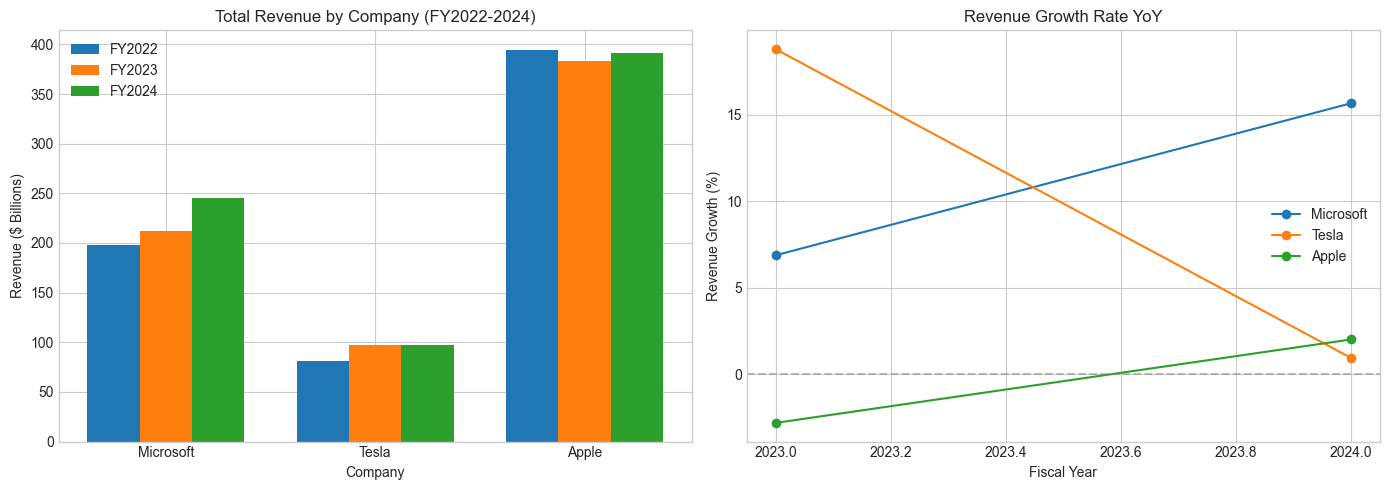

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue bar chart
companies = df['Company'].unique()
years = sorted(df['Fiscal Year'].unique())
x = np.arange(len(companies))
width = 0.25

for i, year in enumerate(years):
    year_data = df[df['Fiscal Year'] == year]
    revenues = [year_data[year_data['Company'] == c]['Total Revenue'].values[0] / 1e9 for c in companies]
    axes[0].bar(x + i * width, revenues, width, label=f'FY{year}')

axes[0].set_xlabel('Company')
axes[0].set_ylabel('Revenue ($ Billions)')
axes[0].set_title('Total Revenue by Company (FY2022-2024)')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(companies)
axes[0].legend()

# Revenue growth line chart
for company in companies:
    company_data = df[df['Company'] == company]
    axes[1].plot(company_data['Fiscal Year'], company_data['Total Revenue Growth (%)'], marker='o', label=company)

axes[1].set_xlabel('Fiscal Year')
axes[1].set_ylabel('Revenue Growth (%)')
axes[1].set_title('Revenue Growth Rate YoY')
axes[1].legend()
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('revenue_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Profitability Analysis

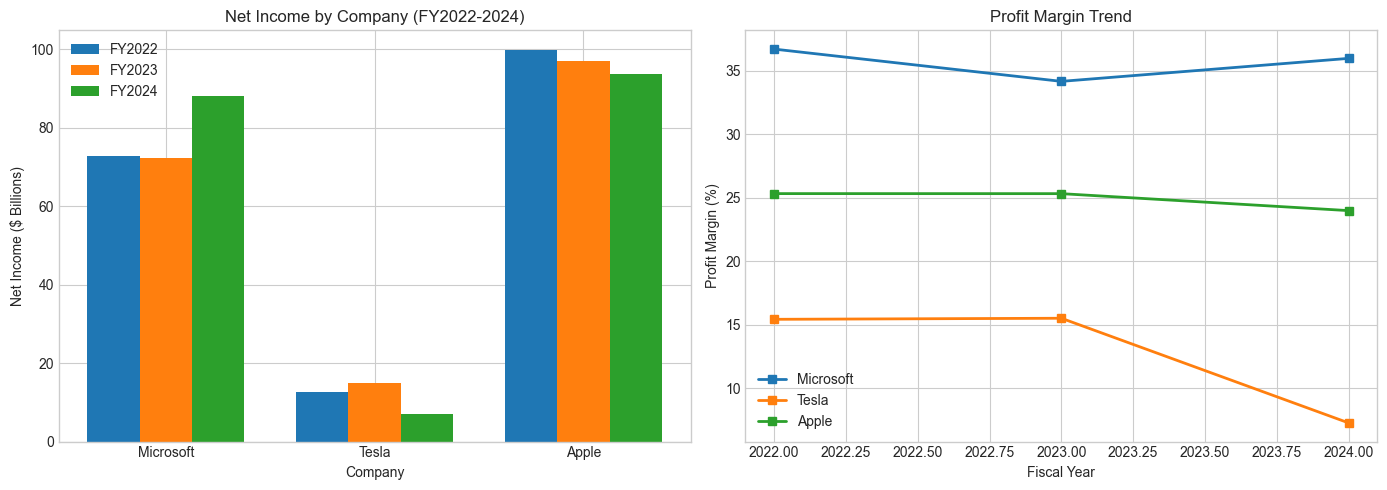

In [7]:
# Calculate profit margin
df['Profit Margin (%)'] = (df['Net Income'] / df['Total Revenue']) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Net Income comparison
for i, year in enumerate(years):
    year_data = df[df['Fiscal Year'] == year]
    net_incomes = [year_data[year_data['Company'] == c]['Net Income'].values[0] / 1e9 for c in companies]
    axes[0].bar(x + i * width, net_incomes, width, label=f'FY{year}')

axes[0].set_xlabel('Company')
axes[0].set_ylabel('Net Income ($ Billions)')
axes[0].set_title('Net Income by Company (FY2022-2024)')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(companies)
axes[0].legend()

# Profit margin trend
for company in companies:
    company_data = df[df['Company'] == company]
    axes[1].plot(company_data['Fiscal Year'], company_data['Profit Margin (%)'], marker='s', linewidth=2, label=company)

axes[1].set_xlabel('Fiscal Year')
axes[1].set_ylabel('Profit Margin (%)')
axes[1].set_title('Profit Margin Trend')
axes[1].legend()

plt.tight_layout()
plt.savefig('profitability_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Financial Health: Assets vs Liabilities

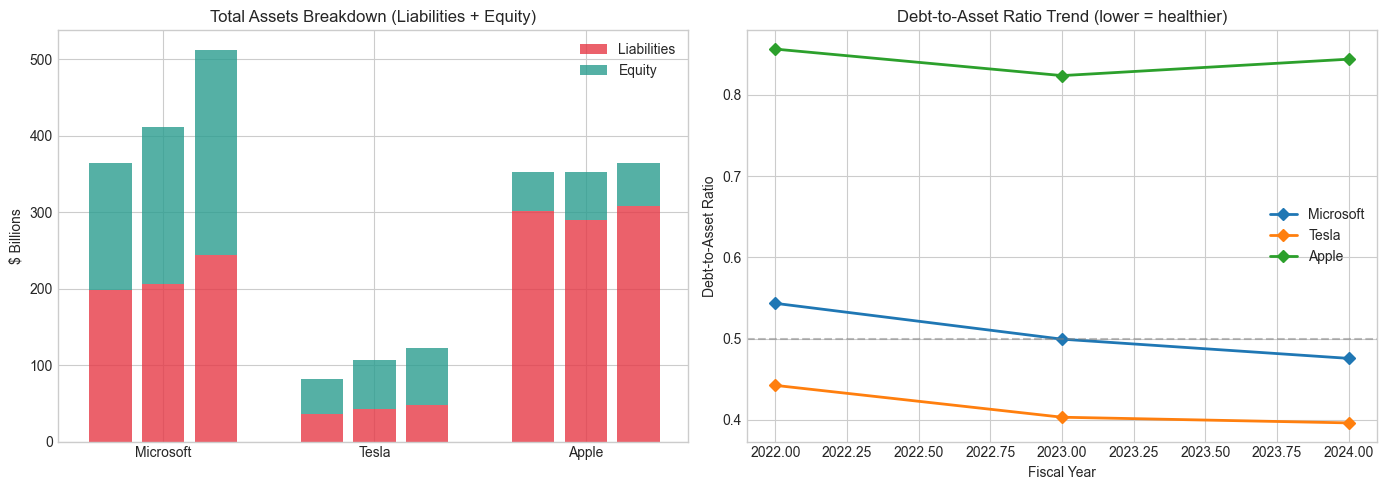

In [8]:
# Debt-to-Asset Ratio
df['Debt to Asset Ratio'] = df['Total Liabilities'] / df['Total Assets']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar: Assets vs Liabilities
for i, company in enumerate(companies):
    company_data = df[df['Company'] == company]
    assets = company_data['Total Assets'].values / 1e9
    liabilities = company_data['Total Liabilities'].values / 1e9
    equity = (company_data['Total Assets'] - company_data['Total Liabilities']).values / 1e9
    
    bar_positions = np.arange(len(years)) + i * (len(years) + 1)
    axes[0].bar(bar_positions, liabilities, label='Liabilities' if i == 0 else '', color='#e63946', alpha=0.8)
    axes[0].bar(bar_positions, equity, bottom=liabilities, label='Equity' if i == 0 else '', color='#2a9d8f', alpha=0.8)
    axes[0].set_xticks(list(axes[0].get_xticks()) + list(bar_positions))

axes[0].set_ylabel('$ Billions')
axes[0].set_title('Total Assets Breakdown (Liabilities + Equity)')
axes[0].legend()
tick_positions = [np.mean(np.arange(len(years)) + i * (len(years) + 1)) for i in range(len(companies))]
axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(companies)

# Debt-to-Asset Ratio trend
for company in companies:
    company_data = df[df['Company'] == company]
    axes[1].plot(company_data['Fiscal Year'], company_data['Debt to Asset Ratio'], marker='D', linewidth=2, label=company)

axes[1].set_xlabel('Fiscal Year')
axes[1].set_ylabel('Debt-to-Asset Ratio')
axes[1].set_title('Debt-to-Asset Ratio Trend (lower = healthier)')
axes[1].legend()
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% threshold')

plt.tight_layout()
plt.savefig('financial_health.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Cash Flow from Operations

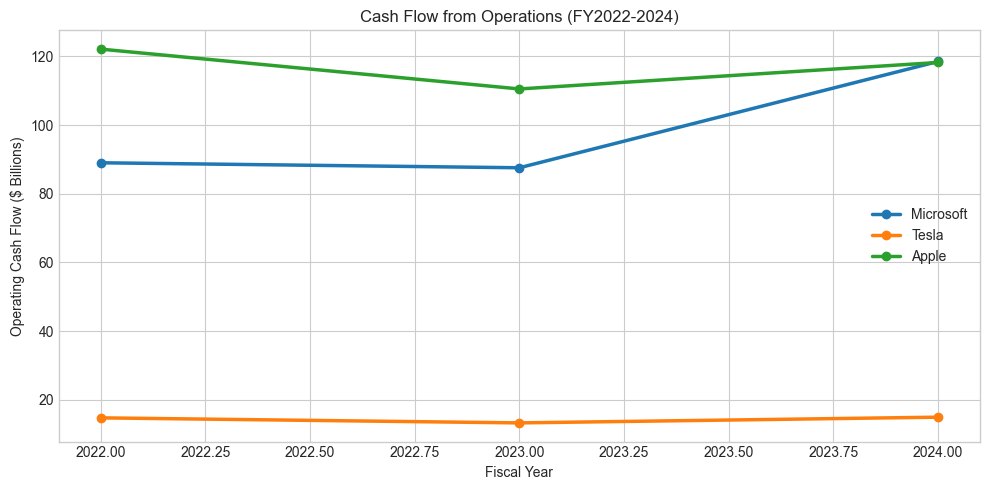

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

for company in companies:
    company_data = df[df['Company'] == company]
    ax.plot(company_data['Fiscal Year'], company_data['Cash Flow from Operations'] / 1e9, 
            marker='o', linewidth=2.5, label=company)

ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Operating Cash Flow ($ Billions)')
ax.set_title('Cash Flow from Operations (FY2022-2024)')
ax.legend()

plt.tight_layout()
plt.savefig('cashflow_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 5: Summary Statistics

In [10]:
# Summary table: latest year (FY2024) snapshot
latest = df[df['Fiscal Year'] == 2024].set_index('Company')

summary = pd.DataFrame({
    'Revenue ($B)': (latest['Total Revenue'] / 1e9).round(1),
    'Net Income ($B)': (latest['Net Income'] / 1e9).round(1),
    'Profit Margin (%)': latest['Profit Margin (%)'].round(1),
    'Total Assets ($B)': (latest['Total Assets'] / 1e9).round(1),
    'Debt-to-Asset Ratio': latest['Debt to Asset Ratio'].round(3),
    'Op. Cash Flow ($B)': (latest['Cash Flow from Operations'] / 1e9).round(1),
})

print('FY2024 Financial Snapshot')
print('=' * 90)
print(summary.to_string())

FY2024 Financial Snapshot
           Revenue ($B)  Net Income ($B)  Profit Margin (%)  Total Assets ($B)  Debt-to-Asset Ratio  Op. Cash Flow ($B)
Company                                                                                                                
Microsoft        245.10            88.10              36.00             512.20                 0.48              118.50
Tesla             97.70             7.10               7.30             122.10                 0.40               14.90
Apple            391.00            93.70              24.00             365.00                 0.84              118.30


In [11]:
# 3-Year Compound Annual Growth Rate (CAGR) for Revenue
print('3-Year Revenue CAGR (FY2022 → FY2024)')
print('=' * 50)
for company in companies:
    company_data = df[df['Company'] == company].sort_values('Fiscal Year')
    rev_start = company_data['Total Revenue'].iloc[0]
    rev_end = company_data['Total Revenue'].iloc[-1]
    cagr = ((rev_end / rev_start) ** (1/2) - 1) * 100  # 2 periods for 3 years
    print(f'  {company}: {cagr:.1f}%')

3-Year Revenue CAGR (FY2022 → FY2024)
  Microsoft: 11.2%
  Tesla: 9.5%
  Apple: -0.4%


---
## Step 6: Preparing Data for AI Chatbot

Format and export the cleaned data in a structure suitable for the AI chatbot.

In [12]:
# Prepare structured data for AI model integration
ai_ready_data = df[['Company', 'Fiscal Year', 'Total Revenue', 'Net Income', 
                     'Total Assets', 'Total Liabilities', 'Cash Flow from Operations',
                     'Shareholders Equity', 'Profit Margin (%)', 'Debt to Asset Ratio',
                     'Total Revenue Growth (%)', 'Net Income Growth (%)']].copy()

# Round derived metrics
ai_ready_data['Profit Margin (%)'] = ai_ready_data['Profit Margin (%)'].round(2)
ai_ready_data['Debt to Asset Ratio'] = ai_ready_data['Debt to Asset Ratio'].round(4)
ai_ready_data['Total Revenue Growth (%)'] = ai_ready_data['Total Revenue Growth (%)'].round(2)
ai_ready_data['Net Income Growth (%)'] = ai_ready_data['Net Income Growth (%)'].round(2)

# Export for chatbot
ai_ready_data.to_csv('ai_chatbot_data.csv', index=False)
print('Exported ai_chatbot_data.csv for AI model integration')
print(f'Shape: {ai_ready_data.shape}')
print()
ai_ready_data

Exported ai_chatbot_data.csv for AI model integration
Shape: (9, 12)



,Company,Fiscal Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Cash Flow from Operations,Shareholders Equity,Profit Margin (%),Debt to Asset Ratio,Total Revenue Growth (%),Net Income Growth (%)
0,Microsoft,2022,198270000000,72738000000,364840000000,198298000000,89035000000,166542000000,36.69,0.54,NaN,NaN
1,Microsoft,2023,211915000000,72361000000,411976000000,205753000000,87582000000,206223000000,34.15,0.50,6.88,-0.52
2,Microsoft,2024,245122000000,88136000000,512163000000,243686000000,118548000000,268477000000,35.96,0.48,15.67,21.80
3,Tesla,2022,81462000000,12556000000,82338000000,36440000000,14724000000,45898000000,15.41,0.44,NaN,NaN
4,Tesla,2023,96773000000,14997000000,106618000000,43009000000,13256000000,63609000000,15.50,0.40,18.80,19.44
5,Tesla,2024,97690000000,7091000000,122070000000,48390000000,14923000000,73680000000,7.26,0.40,0.95,-52.72
6,Apple,2022,394328000000,99803000000,352755000000,302083000000,122151000000,50672000000,25.31,0.86,NaN,NaN
7,Apple,2023,383285000000,96995000000,352583000000,290437000000,110543000000,62146000000,25.31,0.82,-2.80,-2.81
8,Apple,2024,391035000000,93736000000,364980000000,308030000000,118254000000,56950000000,23.97,0.84,2.02,-3.36


---
## Findings and Conclusions

### Microsoft
- **Strongest growth story.** Revenue grew from $198B to $245B (CAGR ~11%), driven by cloud (Azure) and AI investments.
- Net income was flat in FY2022→FY2023 (~$72B) then surged 22% to $88B in FY2024.
- Operating cash flow jumped 35% in FY2024 ($118.5B), signalling strong cash generation.
- Total assets grew 40% over the period, partly reflecting the Activision Blizzard acquisition.
- Profit margin improved from ~37% to ~36%, remaining consistently strong.
- **Assessment: Very healthy financial position with strong growth momentum.**

### Tesla
- **Revenue growth stalled.** Strong 18.8% growth in FY2023 collapsed to just 0.9% in FY2024.
- **Profitability declined sharply.** Net income fell 53% from $15B to $7.1B — margin compressed from 15.5% to 7.3%.
- Operating cash flow remained resilient at ~$14.9B despite the profit decline.
- Total assets grew steadily to $122B, with a healthy debt-to-asset ratio of 0.40.
- **Assessment: Revenue plateau and significant margin compression raise concerns. Strong balance sheet provides buffer, but profitability trend needs watching.**

### Apple
- **Mature, stable business.** Revenue dipped 2.8% in FY2023 then recovered partially in FY2024, still below FY2022 peak.
- Net income has declined each year (from $99.8B to $93.7B), a cumulative 6% drop.
- Profit margin remains high at ~24% but is trending downward.
- Highest debt-to-asset ratio of the three (0.84), reflecting Apple's strategy of leveraging low-cost debt for buybacks.
- Operating cash flow remains very strong at $110-122B annually.
- **Assessment: Financially robust but showing signs of maturity. High leverage is strategic, not distressed. Cash flow generation remains exceptional.**

### Cross-Company Insights for the AI Chatbot

| Dimension | Leader | Key Insight |
|---|---|---|
| Revenue Growth | Microsoft | Only company with consistent double-digit growth |
| Profit Margin | Microsoft (~36%) | Tesla's margin compression is the key risk signal |
| Cash Flow | Apple ($118B) | All three generate massive operating cash flows |
| Balance Sheet Health | Tesla (0.40 D/A) | Apple's high leverage is strategic, not a red flag |
| Growth Momentum | Microsoft | Cloud + AI tailwinds driving acceleration |

### Recommendations for AI Chatbot Design

1. **Trend detection** should be a core capability — the chatbot must flag inflection points like Tesla's margin compression.
2. **Ratio analysis** (profit margin, debt-to-asset, revenue CAGR) provides more actionable insights than raw numbers.
3. **Comparative analysis** across companies adds significant value for GFC's investment clients.
4. The chatbot should be able to contextualise numbers — e.g., Apple's high debt ratio is strategic, not a warning sign.